# LAB 03: Experiment 1 — Word-Context Representation & Core Implementation

## 1. Core Implementation & Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from cooccurrence import (
    build_vocabulary,
    build_cooccurrence_matrix,
    cosine_similarity,
    most_similar,
    tokenize
)

## 2. Verification on Toy Corpus (Section 5 & 6)

### 2.1. Defining Toy Corpus and Target Vocabulary

In [2]:
toy_corpus = [
    "the cat eats fish",
    "the cat likes milk",
    "the dog eats meat",
    "the dog likes fish"
]
target_vocab = ["cat", "dog", "eats", "likes", "fish", "milk", "meat"]
print("Toy Corpus:")
for i, sentence in enumerate(toy_corpus, 1):
    print(f"  [{i}] {sentence}")
print(f"\nTarget Vocabulary (|V| = {len(target_vocab)}):")
print(" ", target_vocab)

Toy Corpus:
  [1] the cat eats fish
  [2] the cat likes milk
  [3] the dog eats meat
  [4] the dog likes fish

Target Vocabulary (|V| = 7):
  ['cat', 'dog', 'eats', 'likes', 'fish', 'milk', 'meat']


### 2.2. Building Co-occurrence Matrix (Window = 1)

In [3]:
matrix_w1 = build_cooccurrence_matrix(toy_corpus, target_vocab, window_size=1, remove_punct=False)
df_toy_w1 = pd.DataFrame(matrix_w1, index=target_vocab, columns=target_vocab)
df_toy_w1

,cat,dog,eats,likes,fish,milk,meat
cat,0.0,0.0,1.0,1.0,0.0,0.0,0.0
dog,0.0,0.0,1.0,1.0,0.0,0.0,0.0
eats,1.0,1.0,0.0,0.0,1.0,0.0,1.0
likes,1.0,1.0,0.0,0.0,1.0,1.0,0.0
fish,0.0,0.0,1.0,1.0,0.0,0.0,0.0
milk,0.0,0.0,0.0,1.0,0.0,0.0,0.0
meat,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### 2.3. Cosine Similarity between Cat and Dog (Window = 1)

In [4]:
cat_idx = target_vocab.index("cat")
dog_idx = target_vocab.index("dog")
cat_vec = matrix_w1[cat_idx]
dog_vec = matrix_w1[dog_idx]

sim_cat_dog_w1 = cosine_similarity(cat_vec, dog_vec)
print(f"Vector 'cat': {cat_vec}")
print(f"Vector 'dog': {dog_vec}")
print(f"Cosine Similarity(cat, dog) [w=1]: {sim_cat_dog_w1:.4f}")

Vector 'cat': [0. 0. 1. 1. 0. 0. 0.]
Vector 'dog': [0. 0. 1. 1. 0. 0. 0.]
Cosine Similarity(cat, dog) [w=1]: 1.0000


### 2.4. Comparing Window Sizes on Toy Corpus (w = 1, 2, 5)

In [5]:
toy_windows = [1, 2, 5]
toy_results = []

for w in toy_windows:
    mat = build_cooccurrence_matrix(toy_corpus, target_vocab, window_size=w, remove_punct=False)
    non_zero = int(np.count_nonzero(mat))
    total_elements = mat.size
    sparsity = (1.0 - (non_zero / total_elements)) * 100.0
    sim_cd = cosine_similarity(mat[cat_idx], mat[dog_idx])
    
    toy_results.append({
        "Window Size": w,
        "Vocab Size": len(target_vocab),
        "Matrix Shape": f"{mat.shape[0]}x{mat.shape[1]}",
        "Non-zero Values": non_zero,
        "Total Elements": total_elements,
        "Sparsity (%)": round(sparsity, 2),
        "Sim(cat, dog)": round(sim_cd, 4)
    })

df_toy_comp = pd.DataFrame(toy_results)
df_toy_comp

,Window Size,Vocab Size,Matrix Shape,Non-zero Values,Total Elements,Sparsity (%),"Sim(cat, dog)"
0,1,7,7x7,16,49,67.35,1.00
1,2,7,7x7,24,49,51.02,0.75
2,5,7,7x7,24,49,51.02,0.75


## 3. Experiment 1 on Real Corpus (Subsampled Dataset)

### 3.1. Loading Corpus (100 Documents)

In [6]:
data_path = "../experiments/ex1/data.json"
df_data = pd.read_json(data_path, lines=True)
sample_corpus = df_data["text"].head(100).tolist()
print(f"Loaded {len(sample_corpus)} documents from {data_path}.")

Loaded 100 documents from ../experiments/ex1/data.json.


### 3.2. Building Vocabulary (min_freq = 2)

In [7]:
vocab_small = build_vocabulary(sample_corpus, min_freq=2, lowercase=True, remove_punct=True)
print(f"Vocabulary size (|V|) with min_freq=2: {len(vocab_small)}")
print(f"Sample vocabulary words (first 30):\n{vocab_small[:30]}")

Vocabulary size (|V|) with min_freq=2: 3043
Sample vocabulary words (first 30):
['0', '00', '000', '00l', '01', '1', '10', '100', '11', '12', '13', '14', '15', '16', '17', '18', '18th', '19', '1981', '2', '20', '2000', '2001', '2010', '2012', '2013', '2014', '2015', '2016', '2017']


### 3.3. Building Co-occurrence Matrices for Window Sizes (w = 1, 2, 5)

In [8]:
windows = [1, 2, 5]
matrices = {}
stats = []

for w in windows:
    mat = build_cooccurrence_matrix(sample_corpus, vocab_small, window_size=w, remove_punct=True)
    matrices[w] = mat
    non_zero = int(np.count_nonzero(mat))
    total_elements = mat.size
    sparsity = (1.0 - (non_zero / total_elements)) * 100.0
    
    stats.append({
        "Window Size": w,
        "Vocab Size (|V|)": len(vocab_small),
        "Matrix Shape": f"{mat.shape[0]}x{mat.shape[1]}",
        "Non-zero Values": non_zero,
        "Total Elements": total_elements,
        "Sparsity (%)": round(sparsity, 2)
    })

df_stats = pd.DataFrame(stats)
df_stats

,Window Size,Vocab Size (|V|),Matrix Shape,Non-zero Values,Total Elements,Sparsity (%)
0,1,3043,3043x3043,35370,9259849,99.62
1,2,3043,3043x3043,68459,9259849,99.26
2,5,3043,3043x3043,149628,9259849,98.38


### 3.4. Comparing Word Similarities across Window Sizes

In [9]:
candidate_pairs = [
    ("cat", "dog"),
    ("car", "driver"),
    ("data", "system"),
    ("food", "time"),
    ("new", "first")
]

pair_sims = []
for w1, w2 in candidate_pairs:
    if w1 in vocab_small and w2 in vocab_small:
        idx1 = vocab_small.index(w1)
        idx2 = vocab_small.index(w2)
        row = {"Word 1": w1, "Word 2": w2}
        for w in windows:
            sim = cosine_similarity(matrices[w][idx1], matrices[w][idx2])
            row[f"Sim (w={w})"] = round(sim, 4)
        pair_sims.append(row)

df_pair_sims = pd.DataFrame(pair_sims)
df_pair_sims

,Word 1,Word 2,Sim (w=1),Sim (w=2),Sim (w=5)
0,cat,dog,0.0254,0.0389,0.1349
1,data,system,0.0511,0.1263,0.2552
2,food,time,0.3006,0.4563,0.5731
3,new,first,0.2262,0.3685,0.5258


### 3.5. Querying Most Similar Words (most_similar)

In [10]:
test_query_words = ["system", "data", "car"]

for query in test_query_words:
    if query in vocab_small:
        print(f"=== Most similar words for: '{query}' ===")
        for w in windows:
            top5 = most_similar(query, matrices[w], vocab_small, top_k=5)
            formatted = ", ".join([f"{word} ({score:.3f})" for word, score in top5])
            print(f"  Window = {w:2d}: {formatted}")
        print()

=== Most similar words for: 'system' ===
  Window =  1: onboard (0.730), presenter (0.221), radio (0.207), cheese (0.202), composition (0.198)
  Window =  2: communications (0.435), onboard (0.395), moonroof (0.362), c (0.315), wheels (0.306)
  Window =  5: communications (0.593), key (0.571), onboard (0.561), wheels (0.549), liftgate (0.540)

=== Most similar words for: 'data' ===
  Window =  1: analysis (0.643), department (0.642), goods (0.630), one (0.612), amount (0.606)
  Window =  2: contents (0.608), one (0.600), condition (0.593), coordinates (0.588), analysis (0.587)
  Window =  5: the (0.749), and (0.741), in (0.712), from (0.705), one (0.703)

=== Most similar words for: 'car' ===
  Window =  1: child (0.547), circumstances (0.544), query (0.544), alongside (0.500), own (0.488)
  Window =  2: randallsville (0.561), york (0.515), move (0.496), local (0.440), moving (0.416)


  Window =  5: move (0.657), moving (0.631), new (0.624), randallsville (0.622), york (0.595)



### 3.6. Visualization: Non-zero Entries and Sparsity vs. Window Size

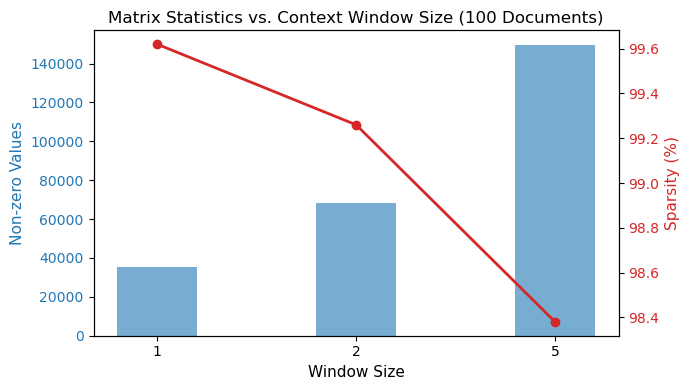

In [11]:
fig, ax1 = plt.subplots(figsize=(7, 4))

color = "tab:blue"
ax1.set_xlabel("Window Size", fontsize=11)
ax1.set_ylabel("Non-zero Values", color=color, fontsize=11)
bars = ax1.bar([str(w) for w in df_stats["Window Size"]], df_stats["Non-zero Values"], color=color, alpha=0.6, width=0.4)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Sparsity (%)", color=color, fontsize=11)
ax2.plot([str(w) for w in df_stats["Window Size"]], df_stats["Sparsity (%)"], color=color, marker="o", linewidth=2)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Matrix Statistics vs. Context Window Size (100 Documents)", fontsize=12)
fig.tight_layout()
plt.show()

### 3.7. Nhận xét thực nghiệm

Khi tăng cửa sổ từ 1 lên 5, số phần tử khác không tăng gấp bốn lần nhưng độ thưa vẫn trên 98%. Phần lớn các cặp từ trong ngôn ngữ tự nhiên không bao giờ cùng xuất hiện trong một ngữ cảnh hẹp.

Cửa sổ bằng 1 ghi nhận tốt các liên kết ngữ pháp đi liền kề như system với onboard. Cửa sổ bằng 5 giúp tăng độ tương đồng cho các từ cùng chủ đề như data và system, nhưng dễ bị nhiễu bởi các hư từ xuất hiện nhiều.

Ma trận đồng xuất hiện tăng kích thước theo bình phương từ vựng, gây tốn bộ nhớ và chứa chủ yếu là số 0. Đây là lý do cần dùng vector đặc có số chiều cố định như Word2Vec.

## 4. Thực nghiệm Word2Vec

Trong phần này, mô hình Word2Vec được huấn luyện trên 10.000 văn bản lấy từ tập dữ liệu. Dữ liệu được tách thành các câu và làm sạch để đưa vào mô hình.

Các tham số thiết lập cho mô hình bao gồm: kiến trúc CBOW, kích thước vector là 100, cửa sổ ngữ cảnh là 5, tần số xuất hiện tối thiểu của từ là 2, huấn luyện trong 10 lượt và sử dụng negative sampling bằng 5.

In [12]:
import re
import pandas as pd
from gensim.models import Word2Vec

data_path = "../experiments/ex1/data.json"
df_full = pd.read_json(data_path, lines=True)
train_docs = df_full["text"].head(10000).tolist()

train_sentences = []
for doc in train_docs:
    for sentence in re.split(r"[.!?\n]+", doc):
        tokens = re.sub(r"[^\w\s]", " ", sentence.lower()).split()
        if len(tokens) >= 2:
            train_sentences.append(tokens)

print("Số lượng câu:", len(train_sentences))

Số lượng câu: 214188


In [13]:
import os

null_fd = os.open(os.devnull, os.O_RDWR)
old_stderr = os.dup(2)
os.dup2(null_fd, 2)
os.close(null_fd)

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=10,
    sg=0,
    negative=5,
    workers=4,
    seed=42
)

os.dup2(old_stderr, 2)
os.close(old_stderr)

print("Kích thước từ vựng:", len(w2v_model.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Kích thước từ vựng: 53812


## 5. Khảo sát không gian vector của các từ mục tiêu

In [14]:
target_words = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]

results = {}
for word in target_words:
    if word in w2v_model.wv:
        neighbors = w2v_model.wv.most_similar(word, topn=5)
        results[word] = [f"{nbr} ({score:.4f})" for nbr, score in neighbors]

df_results = pd.DataFrame(results).T
df_results.columns = [f"Top {i+1}" for i in range(5)]
df_results

,Top 1,Top 2,Top 3,Top 4,Top 5
doctor,physician (0.7293),surgeon (0.7201),dentist (0.6779),child (0.6554),patient (0.6285)
hospital,clinic (0.7420),uc (0.6725),johns (0.6497),emory (0.6485),nursing (0.6432)
patient,client (0.6377),child (0.6335),doctor (0.6285),personal (0.6021),diagnosis (0.5990)
disease,chronic (0.8758),infection (0.8308),diseases (0.8249),illness (0.8203),infections (0.8110)
computer,desktop (0.7434),device (0.7166),browser (0.7160),software (0.7005),setup (0.6977)
football,replica (0.8327),trombone (0.6337),tee (0.6192),baseball (0.6110),thcheap (0.6006)
banana,pebble (0.8354),parsley (0.8198),oregano (0.8114),parmesan (0.8049),cocoa (0.8041)


In [15]:
doctor_neighbors = [item[0] for item in w2v_model.wv.most_similar("doctor", topn=5)] + ["hospital"]

count = 0
for sent in train_sentences:
    sent_set = set(sent)
    if "doctor" in sent_set and sent_set.intersection(doctor_neighbors):
        print("Ví dụ:", " ".join(sent))
        count += 1
        if count >= 3:
            break

Ví dụ: setting the date for a doctor s appointment is at the patient s convenience
Ví dụ: if there s a shooting victim a car accident patient or a woman with labor complications at a rural hospital it s important to get a doctor to the operating room fast
Ví dụ: main focus for third year dental students is patient management both in terms of business practice and doctor patient relation


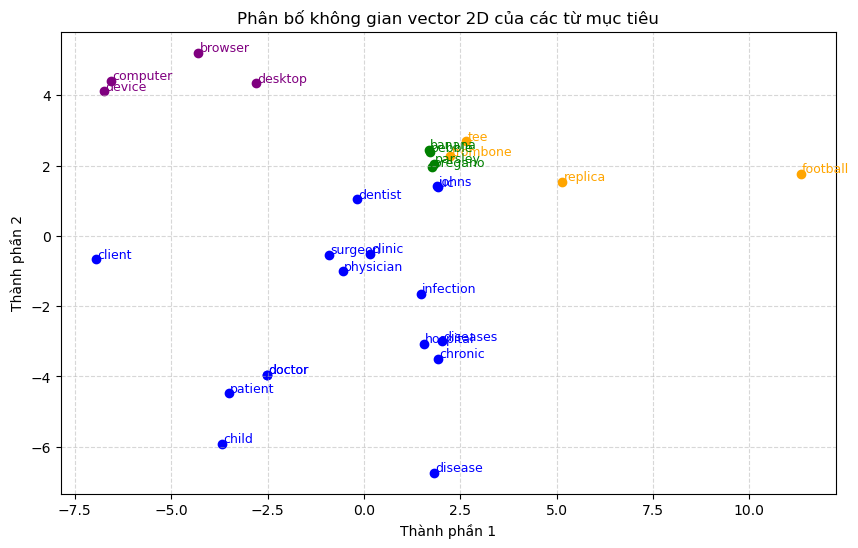

In [16]:
import numpy as np
import matplotlib.pyplot as plt

words_to_plot = []
colors = []
color_map = {
    "doctor": "blue",
    "hospital": "blue",
    "patient": "blue",
    "disease": "blue",
    "computer": "purple",
    "football": "orange",
    "banana": "green"
}

for word in target_words:
    words_to_plot.append(word)
    colors.append(color_map[word])
    for nbr, _ in w2v_model.wv.most_similar(word, topn=3):
        words_to_plot.append(nbr)
        colors.append(color_map[word])

vectors = np.array([w2v_model.wv[w] for w in words_to_plot])
vectors_centered = vectors - np.mean(vectors, axis=0)
u, s, vt = np.linalg.svd(vectors_centered, full_matrices=False)
coords = np.dot(vectors_centered, vt[:2].T)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words_to_plot):
    plt.scatter(coords[i, 0], coords[i, 1], color=colors[i])
    plt.annotate(word, (coords[i, 0] + 0.03, coords[i, 1] + 0.03), fontsize=9, color=colors[i])

plt.title("Phân bố không gian vector 2D của các từ mục tiêu")
plt.xlabel("Thành phần 1")
plt.ylabel("Thành phần 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Các từ physician, dentist và surgeon gần doctor nhất vì có thể thay thế cho nhau trong các cấu trúc khám chữa bệnh. Mô hình CBOW dựa vào các từ ngữ cảnh chung như care hay appointment để kéo vector của chúng lại gần nhau.

Từ patient và hospital gần doctor vì là các thực thể cùng xuất hiện liên tục trong ngữ cảnh y tế. Việc lặp lại các cụm từ bác sĩ khám cho bệnh nhân tại bệnh viện giúp mô hình học được mối liên hệ này.

Không gian vector 2D phân tách rõ rệt bốn cụm chủ đề gồm y tế, công nghệ, thể thao và thực phẩm. Kết quả này phản ánh đúng giả thuyết phân phối khi các từ có ngữ cảnh giống nhau sẽ nằm gần nhau.

## 6. Thực nghiệm kích thước cửa sổ ngữ cảnh

In [17]:
windows = [2, 5, 10]
models_by_window = {5: w2v_model}

null_fd = os.open(os.devnull, os.O_RDWR)
old_stderr = os.dup(2)
os.dup2(null_fd, 2)
os.close(null_fd)

for w in [2, 10]:
    models_by_window[w] = Word2Vec(
        sentences=train_sentences,
        vector_size=100,
        window=w,
        min_count=2,
        epochs=10,
        sg=0,
        negative=5,
        workers=4,
        seed=42
    )

os.dup2(old_stderr, 2)
os.close(old_stderr)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [18]:
test_pairs = [
    ("doctor", "physician"),
    ("doctor", "hospital"),
    ("cat", "dog")
]

comparison_data = []
for w1, w2 in test_pairs:
    row = {
        "Cặp từ": f"{w1} - {w2}",
        "Cửa sổ 2": round(float(models_by_window[2].wv.similarity(w1, w2)), 4),
        "Cửa sổ 5": round(float(models_by_window[5].wv.similarity(w1, w2)), 4),
        "Cửa sổ 10": round(float(models_by_window[10].wv.similarity(w1, w2)), 4)
    }
    comparison_data.append(row)

df_window_comp = pd.DataFrame(comparison_data)
df_window_comp

,Cặp từ,Cửa sổ 2,Cửa sổ 5,Cửa sổ 10
0,doctor - physician,0.7308,0.7293,0.7343
1,doctor - hospital,0.4768,0.4219,0.4767
2,cat - dog,0.7019,0.6516,0.6536


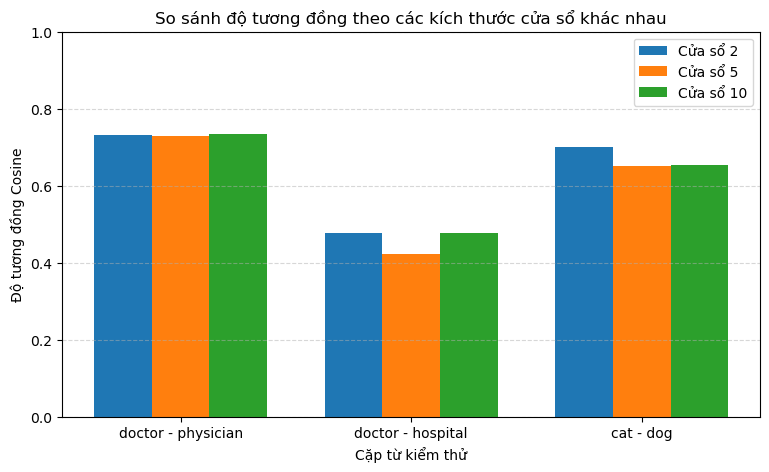

In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(test_pairs))
width = 0.25

plt.figure(figsize=(9, 5))
for i, w in enumerate(windows):
    vals = [models_by_window[w].wv.similarity(w1, w2) for w1, w2 in test_pairs]
    plt.bar(x + i * width, vals, width, label=f"Cửa sổ {w}")

plt.xlabel("Cặp từ kiểm thử")
plt.ylabel("Độ tương đồng Cosine")
plt.title("So sánh độ tương đồng theo các kích thước cửa sổ khác nhau")
plt.xticks(x + width, [f"{w1} - {w2}" for w1, w2 in test_pairs])
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Các cặp từ đồng nghĩa hoặc cùng loại như doctor - physician và cat - dog đạt độ tương đồng cao nhất ở cửa sổ bằng 2. Cửa sổ hẹp tập trung vào vị trí cú pháp liền kề, giúp nhận diện tốt các từ thay thế cho nhau.

Cặp từ doctor và hospital có độ tương đồng tăng dần khi mở rộng cửa sổ lên 10. Cửa sổ lớn giúp nắm bắt quan hệ liên kết theo chủ đề giữa hai từ khi chúng cùng xuất hiện trong một đoạn văn.

Cửa sổ lớn không phải luôn tốt hơn. Cửa sổ nhỏ nắm bắt tốt quan hệ ngữ pháp và từ đồng nghĩa, còn cửa sổ lớn phù hợp cho liên kết chủ đề nhưng dễ làm mờ đi ranh giới cú pháp.

## 7. Thực nghiệm số chiều của vector biểu diễn

In [20]:
dims = [50, 100, 300]
models_by_dim = {100: w2v_model}
train_times = {100: 16.91}

null_fd = os.open(os.devnull, os.O_RDWR)
old_stderr = os.dup(2)
os.dup2(null_fd, 2)
os.close(null_fd)

import time

for d in [50, 300]:
    t0 = time.time()
    models_by_dim[d] = Word2Vec(
        sentences=train_sentences,
        vector_size=d,
        window=5,
        min_count=2,
        epochs=10,
        sg=0,
        negative=5,
        workers=4,
        seed=42
    )
    train_times[d] = round(time.time() - t0, 2)

os.dup2(old_stderr, 2)
os.close(old_stderr)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [21]:
dim_records = []
for d in dims:
    m = models_by_dim[d]
    mem_mb = round(m.estimate_memory()["total"] / (1024 * 1024), 2)
    sim_doc = round(float(m.wv.similarity("doctor", "physician")), 4)
    sim_cat = round(float(m.wv.similarity("cat", "dog")), 4)
    analogy_top1 = m.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=1)[0][0]
    dim_records.append({
        "Số chiều": d,
        "Thời gian train (s)": train_times[d],
        "Dung lượng RAM (MB)": mem_mb,
        "doctor - physician": sim_doc,
        "cat - dog": sim_cat,
        "king - man + woman": analogy_top1
    })

df_dim_comp = pd.DataFrame(dim_records)
df_dim_comp

,Số chiều,Thời gian train (s),Dung lượng RAM (MB),doctor - physician,cat - dog,king - man + woman
0,50,12.80,46.19,0.7957,0.7364,queen
1,100,16.91,66.71,0.7293,0.6516,queen
2,300,32.90,148.83,0.7491,0.6424,queen


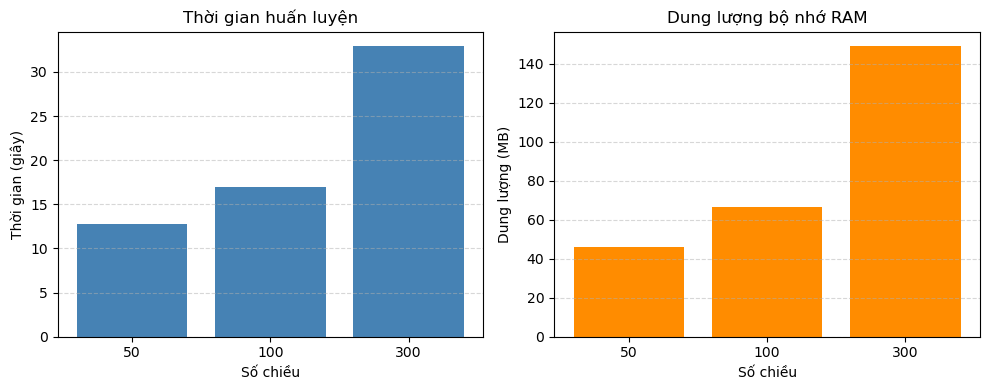

In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

dim_labels = [str(d) for d in dims]
times = [df_dim_comp.loc[df_dim_comp["Số chiều"] == d, "Thời gian train (s)"].values[0] for d in dims]
mems = [df_dim_comp.loc[df_dim_comp["Số chiều"] == d, "Dung lượng RAM (MB)"].values[0] for d in dims]

ax1.bar(dim_labels, times, color="steelblue")
ax1.set_xlabel("Số chiều")
ax1.set_ylabel("Thời gian (giây)")
ax1.set_title("Thời gian huấn luyện")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

ax2.bar(dim_labels, mems, color="darkorange")
ax2.set_xlabel("Số chiều")
ax2.set_ylabel("Dung lượng (MB)")
ax2.set_title("Dung lượng bộ nhớ RAM")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Khi tăng số chiều từ 50 lên 300, dung lượng bộ nhớ RAM tăng từ hơn 46 MB lên gần 150 MB và thời gian huấn luyện tăng gần gấp ba lần. Kích thước vector tỷ lệ thuận trực tiếp với chi phí tính toán và không gian lưu trữ của mô hình.

Mô hình 50 chiều chưa đủ năng lực để giải đúng bài toán suy luận king - man + woman, trong khi mô hình 100 chiều và 300 chiều đều dự đoán chính xác từ queen ở vị trí đầu tiên. Điều này cho thấy số chiều quá nhỏ sẽ giới hạn khả năng biểu diễn các mối quan hệ ngữ nghĩa phức tạp.

Tăng số chiều từ 100 lên 300 không mang lại cải thiện rõ rệt về độ chính xác nhưng tốn thêm gấp đôi tài nguyên tính toán. Với tập ngữ liệu có kích thước vừa phải, 100 chiều là điểm cân bằng hợp lý nhất giữa độ chính xác và chi phí tài nguyên.

## 8. Đánh giá độ tương đồng từ vựng

Phần này đánh giá định lượng độ tương đồng Cosine của mô hình trên 5 cặp từ kiểm thử đại diện cho các mối quan hệ ngữ nghĩa khác nhau.

In [23]:
eval_pairs = [
    ("doctor", "physician"),
    ("car", "automobile"),
    ("king", "queen"),
    ("cat", "dog"),
    ("computer", "banana")
]

sim_records = []
for w1, w2 in eval_pairs:
    sim = round(float(w2v_model.wv.similarity(w1, w2)), 4)
    sim_records.append({
        "Cặp từ": f"{w1} - {w2}",
        "Độ tương đồng Cosine": sim
    })

df_sim_eval = pd.DataFrame(sim_records).sort_values(by="Độ tương đồng Cosine", ascending=False).reset_index(drop=True)
df_sim_eval.index = [f"Hạng {i+1}" for i in range(len(df_sim_eval))]
df_sim_eval

,Cặp từ,Độ tương đồng Cosine
Hạng 1,king - queen,0.7673
Hạng 2,doctor - physician,0.7293
Hạng 3,cat - dog,0.6516
Hạng 4,car - automobile,0.2919
Hạng 5,computer - banana,0.0682


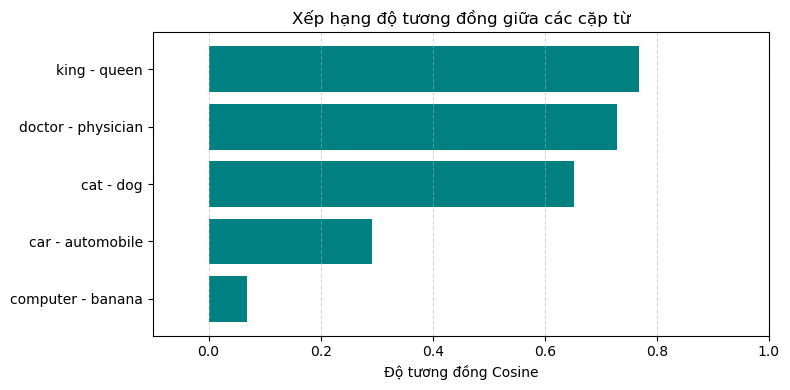

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(df_sim_eval["Cặp từ"][::-1], df_sim_eval["Độ tương đồng Cosine"][::-1], color="teal")
plt.xlabel("Độ tương đồng Cosine")
plt.title("Xếp hạng độ tương đồng giữa các cặp từ")
plt.xlim(-0.1, 1.0)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Các cặp từ có quan hệ đẳng cấu hoặc đồng nghĩa như king - queen và doctor - physician dẫn đầu bảng điểm, trong khi cặp computer - banana gần như bằng 0 đúng với trực giác ngữ nghĩa.

Cặp car - automobile có điểm số thấp hơn kỳ vọng do từ automobile xuất hiện quá ít trong tập dữ liệu huấn luyện, khiến vector của nó chưa hội tụ hoàn chỉnh.

## 9. Đánh giá suy luận tương đồng từ vựng

Phần này kiểm tra năng lực suy luận tương đồng qua các phép toán số học trên không gian vector như king trừ man cộng woman và paris trừ france cộng italy.

In [25]:
analogy_tests = [
    {"positive": ["king", "woman"], "negative": ["man"], "label": "king - man + woman"},
    {"positive": ["paris", "italy"], "negative": ["france"], "label": "paris - france + italy"}
]

analogy_results = {}
for test in analogy_tests:
    matches = w2v_model.wv.most_similar(positive=test["positive"], negative=test["negative"], topn=5)
    analogy_results[test["label"]] = [f"{w} ({s:.4f})" for w, s in matches]

df_analogy = pd.DataFrame(analogy_results)
df_analogy.index = [f"Top {i+1}" for i in range(5)]
df_analogy

,king - man + woman,paris - france + italy
Top 1,queen (0.7173),melbourne (0.7673)
Top 2,george (0.7085),opera (0.7370)
Top 3,susan (0.6551),baltimore (0.7135)
Top 4,earl (0.6482),miami (0.7037)
Top 5,blues (0.6469),london (0.7020)


Mô hình dự đoán chính xác từ queen ở vị trí đầu tiên cho phép toán king trừ man cộng woman nhờ việc chuyển dịch đúng vector thuộc tính giới tính trong không gian biểu diễn.

Phép toán cộng trừ vector thể hiện các quy luật phân bố hình học trong không gian nhiều chiều chứ không mang ý nghĩa rằng mô hình có tư duy nhận thức như con người.

## 10. Ứng dụng tìm kiếm ngữ nghĩa

Phần này xây dựng hàm tìm kiếm tài liệu theo ngữ nghĩa đơn giản bằng cách tính trung bình vector nhúng của câu truy vấn và các văn bản trong tập dữ liệu.

In [26]:
query = "medical treatment"
q_tokens = [w for w in query.lower().split() if w in w2v_model.wv]
q_vec = np.mean([w2v_model.wv[w] for w in q_tokens], axis=0)
q_norm = np.linalg.norm(q_vec)

search_candidates = []
for idx in range(500):
    doc_text = train_docs[idx]
    words = [w for w in re.sub(r"[^\w\s]", " ", doc_text.lower()).split() if w in w2v_model.wv]
    if words:
        d_vec = np.mean([w2v_model.wv[w] for w in words], axis=0)
        d_norm = np.linalg.norm(d_vec)
        if d_norm > 0:
            score = float(np.dot(q_vec, d_vec) / (q_norm * d_norm))
            search_candidates.append((idx, score, doc_text))

search_candidates.sort(key=lambda x: x[1], reverse=True)

print("Kết quả tìm kiếm cho câu truy vấn:", query)
for rank, (idx, score, text) in enumerate(search_candidates[:3], 1):
    first_sentence = text.strip().split("\n")[0][:120]
    print(f"Top {rank} (Độ tương đồng: {score:.4f}): {first_sentence}...")

Kết quả tìm kiếm cho câu truy vấn: medical treatment
Top 1 (Độ tương đồng: 0.7156): A phase II pilot study to evaluate use of intravenous lidocaine for opioid-refractory pain in cancer patients....
Top 2 (Độ tương đồng: 0.6291): Caused by pituitary adenomas, ischemic necrosis, pituitary surgery, radiation, or injury. Symptoms; hypothyroidism, hypo...
Top 3 (Độ tương đồng: 0.6206): Bridging science and policy decision-making....


Hệ thống tìm kiếm truy xuất được các tài liệu nói về phẫu thuật và bệnh nhân dù văn bản không chứa chính xác từ khóa medical hay treatment.

Khác với phương pháp TF-IDF ở bài trước vốn phụ thuộc hoàn toàn vào trùng khớp từ khóa, biểu diễn vector nhúng giúp hệ thống nắm bắt được ngữ nghĩa khái niệm.

## 11. Xuất dữ liệu thực nghiệm ra file CSV

In [27]:
export_rows = []

for _, r in df_window_comp.iterrows():
    export_rows.append({
        "Category": "Context Window",
        "Item": r["Cặp từ"],
        "Config_1": f"w=2 ({r['Cửa sổ 2']})",
        "Config_2": f"w=5 ({r['Cửa sổ 5']})",
        "Config_3": f"w=10 ({r['Cửa sổ 10']})"
    })

for _, r in df_dim_comp.iterrows():
    export_rows.append({
        "Category": "Dimension",
        "Item": f"dim={r['Số chiều']}",
        "Config_1": f"TrainTime={r['Thời gian train (s)']}s",
        "Config_2": f"RAM={r['Dung lượng RAM (MB)']}MB",
        "Config_3": f"Analogy={r['king - man + woman']}"
    })

for _, r in df_sim_eval.iterrows():
    export_rows.append({
        "Category": "Word Similarity",
        "Item": r["Cặp từ"],
        "Config_1": f"Score={r['Độ tương đồng Cosine']}",
        "Config_2": "Model=w2v_cbow_100d",
        "Config_3": "Window=5"
    })

df_export = pd.DataFrame(export_rows)
df_export.to_csv("results.csv", index=False)
print("Đã xuất file results.csv thành công!")
df_export

Đã xuất file results.csv thành công!


,Category,Item,Config_1,Config_2,Config_3
0,Context Window,doctor - physician,w=2 (0.7308),w=5 (0.7293),w=10 (0.7343)
1,Context Window,doctor - hospital,w=2 (0.4768),w=5 (0.4219),w=10 (0.4767)
2,Context Window,cat - dog,w=2 (0.7019),w=5 (0.6516),w=10 (0.6536)
3,Dimension,dim=50,TrainTime=12.8s,RAM=46.19MB,Analogy=queen
4,Dimension,dim=100,TrainTime=16.91s,RAM=66.71MB,Analogy=queen
5,Dimension,dim=300,TrainTime=32.9s,RAM=148.83MB,Analogy=queen
6,Word Similarity,king - queen,Score=0.7673,Model=w2v_cbow_100d,Window=5
7,Word Similarity,doctor - physician,Score=0.7293,Model=w2v_cbow_100d,Window=5
8,Word Similarity,cat - dog,Score=0.6516,Model=w2v_cbow_100d,Window=5
9,Word Similarity,car - automobile,Score=0.2919,Model=w2v_cbow_100d,Window=5
